In [ ]:
# Encoding:

import pandas as pd
import joblib
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

df = pd.read_csv(r"C:\Users\Balaji\AppData\Roaming\Python\Python312\Scripts\Selected_Features.csv")

x = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

# One-hot Encoding for Categorical Features:
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore") # drop for removing first column,sparse_output=False - normal numpy array output,handle_unknown="ignore" unknown categories ignore pandrathu
encoded_arr = ohe.fit_transform(x[["Soil_Type", "Wilderness_Area"]])

# Dataframe conversion:
encoded_df = pd.DataFrame(encoded_arr,columns=ohe.get_feature_names_out(["Soil_Type", "Wilderness_Area"]))

# Dropping Original Columns:
x = x.drop(["Soil_Type", "Wilderness_Area"],axis=1)

# Combining Encoded columns with Original Data:
x = pd.concat([x.reset_index(drop=True),encoded_df.reset_index(drop=True)],axis=1)

# Label Encoders for Target:
le = LabelEncoder()
y = le.fit_transform(y)

# Saving Encoder:
joblib.dump(ohe, "onehot_encoder.pkl")
joblib.dump(le, "label_encoder.pkl")




In [2]:
joblib.dump(ohe, "onehot_encoder.pkl")

['onehot_encoder.pkl']

In [2]:
#Output:
print("Encoded Feature Data:")
print(x.head())

print()

print("Encoded Target:")
print(y[:5])

Encoded Feature Data:
   Elevation  Horizontal_Distance_To_Roadways  \
0       2596                              510   
1       2590                              390   
2       2804                             3180   
3       2785                             3090   
4       2595                              391   

   Horizontal_Distance_To_Fire_Points  Soil_Type_2  Soil_Type_3  Soil_Type_4  \
0                                6279          0.0          0.0          0.0   
1                                6225          0.0          0.0          0.0   
2                                6121          0.0          0.0          0.0   
3                                6211          0.0          0.0          0.0   
4                                6172          0.0          0.0          0.0   

   Soil_Type_5  Soil_Type_6  Soil_Type_7  Soil_Type_8  ...  Soil_Type_34  \
0          0.0          0.0          0.0          0.0  ...           0.0   
1          0.0          0.0          0.0          

In [3]:
# Train,Test,Split and SMOTE Oversampling:
# Avoiding Random OverSampling for avoiding existing minority rows duplicates
# SMOTE oversampling produces synthetic data from the minority class
# Avoiding undersampling to prevent Data loss
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train,y_train)


In [15]:
x_train_smote.shape

(577087, 44)

In [16]:
print(x_train_smote.columns)

Index(['Elevation', 'Horizontal_Distance_To_Roadways',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type_2', 'Soil_Type_3',
       'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7',
       'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11',
       'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_16',
       'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20',
       'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24',
       'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28',
       'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32',
       'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36',
       'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39', 'Soil_Type_40',
       'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4'],
      dtype='object')


In [20]:
y_train_smote[:100]

array([4, 6, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 6, 6, 4, 5, 4,
       4, 6, 6, 4, 4, 4, 4, 4, 1, 4, 4, 6, 4, 4, 4, 4, 6, 0, 4, 6, 6, 6,
       3, 4, 4, 4, 6, 4, 6, 4, 4, 4, 4, 6, 4, 6, 4, 4, 4, 4, 4, 6, 4, 1,
       4, 6, 4, 4, 4, 3, 6, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 1, 0, 4, 6, 4, 6, 4, 6, 4, 4, 4])



Model Name - Decision Tree
************************************************************

 Accuraccy Score :93.9%

 Classification Report: 

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       614
           1       0.90      0.88      0.89       432
           2       0.78      0.79      0.78       432
           3       0.91      0.95      0.93       432
           4       0.97      0.96      0.96     20610
           5       0.75      0.77      0.76       432
           6       0.89      0.90      0.89      6222

    accuracy                           0.94     29174
   macro avg       0.86      0.87      0.87     29174
weighted avg       0.94      0.94      0.94     29174


 Confusion Matrix: 

[[  538     0     4     0    57     8     7]
 [    0   380    24     0     0    28     0]
 [    9    17   340     0     1    64     1]
 [    0     0     0   412     5     0    15]
 [   92     0     6     7 19799     8   698]
 [    6    27 

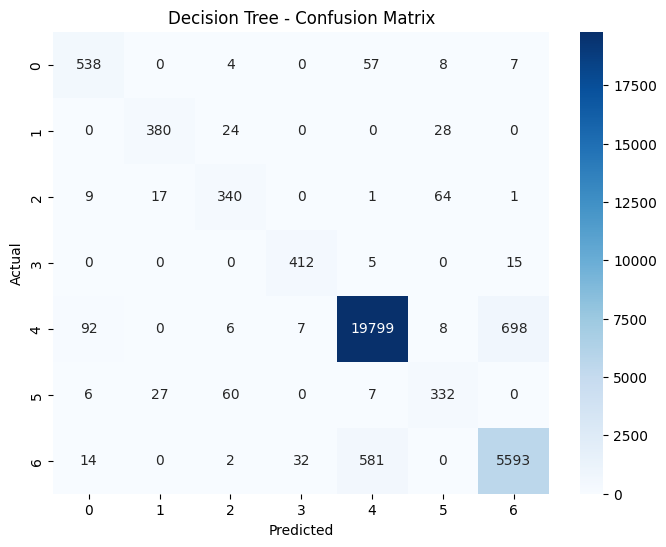



Model Name - Random Forest
************************************************************

 Accuraccy Score :94.97%

 Classification Report: 

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       614
           1       0.92      0.90      0.91       432
           2       0.81      0.86      0.83       432
           3       0.93      0.97      0.95       432
           4       0.98      0.96      0.97     20610
           5       0.79      0.81      0.80       432
           6       0.90      0.92      0.91      6222

    accuracy                           0.95     29174
   macro avg       0.88      0.91      0.89     29174
weighted avg       0.95      0.95      0.95     29174


 Confusion Matrix: 

[[  563     0     2     0    38    10     1]
 [    0   389    15     0     0    28     0]
 [    7    12   370     0     2    41     0]
 [    0     0     0   421     3     1     7]
 [   80     0    11     4 19882    12   621]
 [    2    20

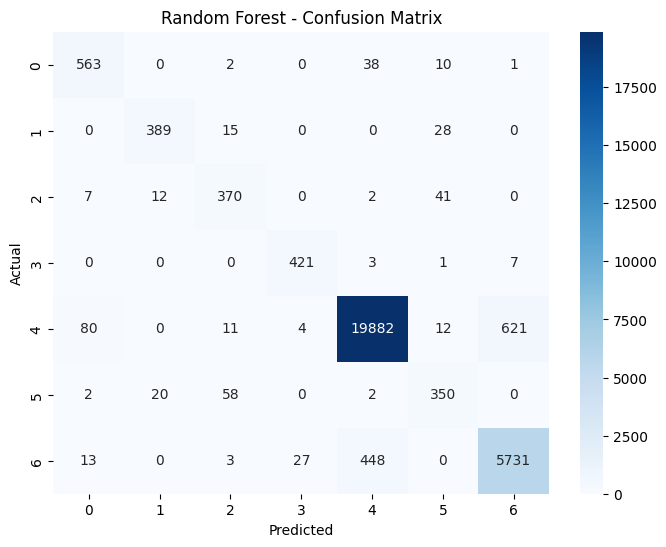



Model Name - AdaBoost
************************************************************


C:\Users\Balaji\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



 Accuraccy Score :58.2%

 Classification Report: 

              precision    recall  f1-score   support

           0       0.43      0.39      0.41       614
           1       0.54      0.96      0.69       432
           2       0.52      0.20      0.29       432
           3       0.00      0.00      0.00       432
           4       0.88      0.54      0.67     20610
           5       0.42      0.33      0.37       432
           6       0.33      0.79      0.47      6222

    accuracy                           0.58     29174
   macro avg       0.45      0.46      0.42     29174
weighted avg       0.73      0.58      0.60     29174


 Confusion Matrix: 

[[  238     0     0     0   272    27    77]
 [    0   415    17     0     0     0     0]
 [   36   160    87     0     0   149     0]
 [    4     0     0     0     0     0   428]
 [  143     0     2     0 11171    18  9276]
 [   38   190    61     0     0   143     0]
 [   89     0     0     0  1203     4  4926]]


C:\Users\Balaji\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Balaji\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Balaji\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

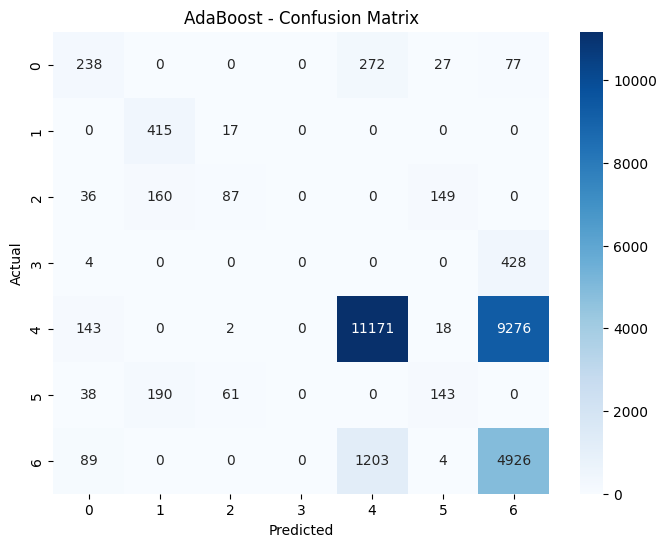



Model Name - Gradient Boosting
************************************************************

 Accuraccy Score :79.15%

 Classification Report: 

              precision    recall  f1-score   support

           0       0.34      0.88      0.49       614
           1       0.82      0.89      0.86       432
           2       0.67      0.76      0.72       432
           3       0.72      0.97      0.83       432
           4       0.92      0.80      0.86     20610
           5       0.70      0.64      0.67       432
           6       0.60      0.73      0.66      6222

    accuracy                           0.79     29174
   macro avg       0.68      0.81      0.73     29174
weighted avg       0.83      0.79      0.80     29174


 Confusion Matrix: 

[[  540     0    21     0    37    15     1]
 [    0   385    15     0     0    32     0]
 [   11    33   330     0     0    58     0]
 [    4     0     0   417     0     0    11]
 [  927     0    21    21 16582    11  3048]
 [   11  

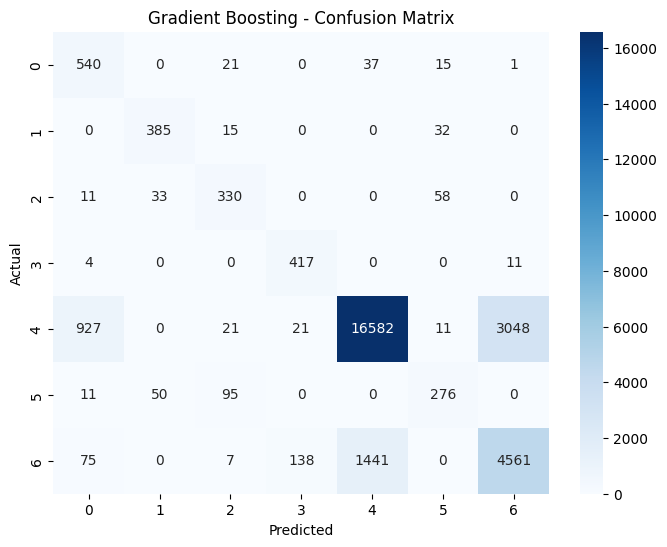



Model Name - XGBoost
************************************************************

 Accuraccy Score :88.6%

 Classification Report: 

              precision    recall  f1-score   support

           0       0.65      0.95      0.77       614
           1       0.92      0.91      0.92       432
           2       0.79      0.84      0.81       432
           3       0.90      0.98      0.94       432
           4       0.96      0.89      0.92     20610
           5       0.78      0.77      0.77       432
           6       0.73      0.87      0.80      6222

    accuracy                           0.89     29174
   macro avg       0.82      0.89      0.85     29174
weighted avg       0.90      0.89      0.89     29174


 Confusion Matrix: 

[[  582     0     3     0    19     9     1]
 [    0   395    14     0     0    23     0]
 [    9    11   364     0     1    47     0]
 [    2     0     0   425     0     0     5]
 [  260     0    11     4 18310    14  2011]
 [    8    23    67 

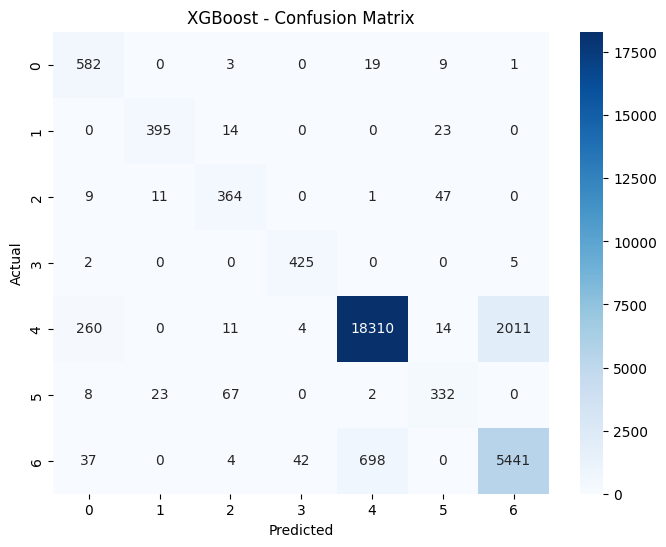



Model Name - KNN
************************************************************

 Accuraccy Score :87.82%

 Classification Report: 

              precision    recall  f1-score   support

           0       0.50      0.90      0.65       614
           1       0.84      0.84      0.84       432
           2       0.47      0.65      0.54       432
           3       0.79      0.94      0.86       432
           4       0.98      0.88      0.92     20610
           5       0.40      0.62      0.49       432
           6       0.77      0.92      0.84      6222

    accuracy                           0.88     29174
   macro avg       0.68      0.82      0.73     29174
weighted avg       0.90      0.88      0.89     29174


 Confusion Matrix: 

[[  554     0     5     0    35    14     6]
 [    0   365    27     0     0    40     0]
 [   10    30   282     0    17    92     1]
 [    0     0     0   405     3     0    24]
 [  482     0   184    22 18043   246  1633]
 [    7    40    94    

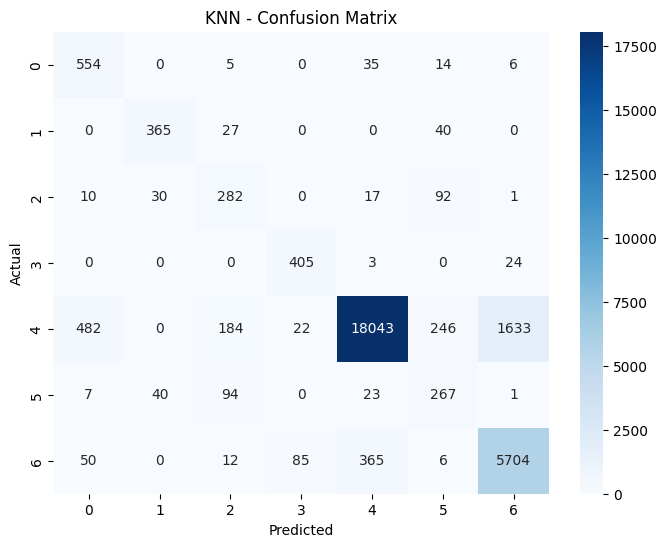

In [21]:
#Model Building:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier)
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

models = { "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42,eval_metric='mlogloss'),
        "KNN": KNeighborsClassifier()}

for model_name,model in models.items():    
    print("\n")
    print("="*60)
    print(f"Model Name - {model_name}")
    print("*"*60)
    
    # Model Training:
    model.fit(x_train_smote, y_train_smote)
    
    # Prediction:
    y_pred = model.predict(x_test)
    
    # Accuraccy:
    accu = accuracy_score(y_test, y_pred)
    print(f"\n Accuraccy Score :{round(accu*100,2)}%")
    
    # Classification Report:
    print("\n Classification Report: \n")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix:
    cm = confusion_matrix(y_test, y_pred)
    print("\n Confusion Matrix: \n")
    print(cm)
    
    # Confusion Matrix Heat Map:
    plt.figure(figsize=(8,6))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Inference:
1) Highest Overall Accuracy: Random Forest achieved the highest test accuracy among all trained models (~95%), outperforming XGBoost and other classifiers.
2) Better Minority Class Performance: The model produced strong recall and F1-scores even for minority forest cover classes after SMOTE balancing.
3) Balanced Precision and Recall: Precision, recall, and F1-score values were consistently balanced across most classes, indicating stable predictions.
4) Lower Overfitting Ris: Training and testing accuracies were close, showing better generalization compared to models like Decision Tree.
5) Strong Macro Average Score: The macro-average F1-score was significantly better, meaning the model handled all classes more fairly instead of favoring majority classes.
6) Better Confusion Matrix Distribution: The confusion matrix showed stronger diagonal values and fewer severe class misclassifications
7) Handles High-Dimensional Encoded Features Efficiently: Random Forest performed well even after One-Hot Encoding expanded the feature space to 44 columns.
8) Works Very Well for Tabular Data: Random Forest is highly effective for structured/tabular datasets like forest cover prediction problems.
9) Robust to Noise and Outliers: The algorithm remained stable despite class imbalance, categorical encoding, and environmental feature variations.
10) Easier and Faster Hyperparameter Optimization: Compared to boosting models, Random Forest tuning is simpler, computationally efficient, and provides stable improvements without aggressive overfitting.

Conclusion:
Random Forest was selected as the final model because it provided the best combination of:
1) High accuracy,
2) Balanced multiclass performance,
3) Better generalization,
4) Stable minority class prediction,
5) And lower overfitting risk compared to the other evaluated models.

Note: Since the Random Forest is already producing some good acuracy score. We are skipping the Hyperparametric Tuning.

In [ ]:
# Taking Random Forest and saving it as Pickle file.
from sklearn.ensemble import RandomForestClassifier
import pickle

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_smote,y_train_smote) # Model Training
y_pred = rf_model.predict(x_test) # Predicting

train_accuracy = rf_model.score(x_train_smote,y_train_smote) # Training Acuracy
test_accuracy = rf_model.score(x_test,y_test) # Test Acuracy

print("=" * 60)
print("Model Name - Random Forest")
print("=" * 60)
print(f"\nTraining Accuracy : {train_accuracy*100}%")
print(f"Testing Accuracy  : {test_accuracy*100}%")

#Saving file:
with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("\n !....Random Forest model saved successfully....!")

Model Name - Random Forest

Training Accuracy : 99.99948014770736%
Testing Accuracy  : 94.96812230067869%

 !....Random Forest model saved successfully....!
